# MAC Grid Solver — Validation

Internal correctness checks for each phase of `MAC_Grid_Solver_Plan.md`.
Phases 1-5 have no standalone demo notebook of their own (they're solver
internals used by the Phase 6/7 benchmarks), so their checks are run and
plotted here instead of only printed -- every figure is saved to `media/`
as the actual evidence a phase works, not just a pass/fail transcript.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

import grid as g
import operators as op

MEDIA_DIR = Path('media')
MEDIA_DIR.mkdir(exist_ok=True)

failures = []

def check(name, cond, detail=""):
    status = "PASS" if cond else "FAIL"
    print(f"[{status}] {name}  {detail}")
    if not cond:
        failures.append(name)

def save(fig, name):
    path = MEDIA_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=path))

## Phase 1 — Grid & operators

[PASS] u_mask/v_mask shapes  
[PASS] u-face into/out of obstacle is blocked  
[PASS] u-face away from obstacle is open  
[PASS] domain-edge u-face is open  
[PASS] v-face into obstacle is blocked  


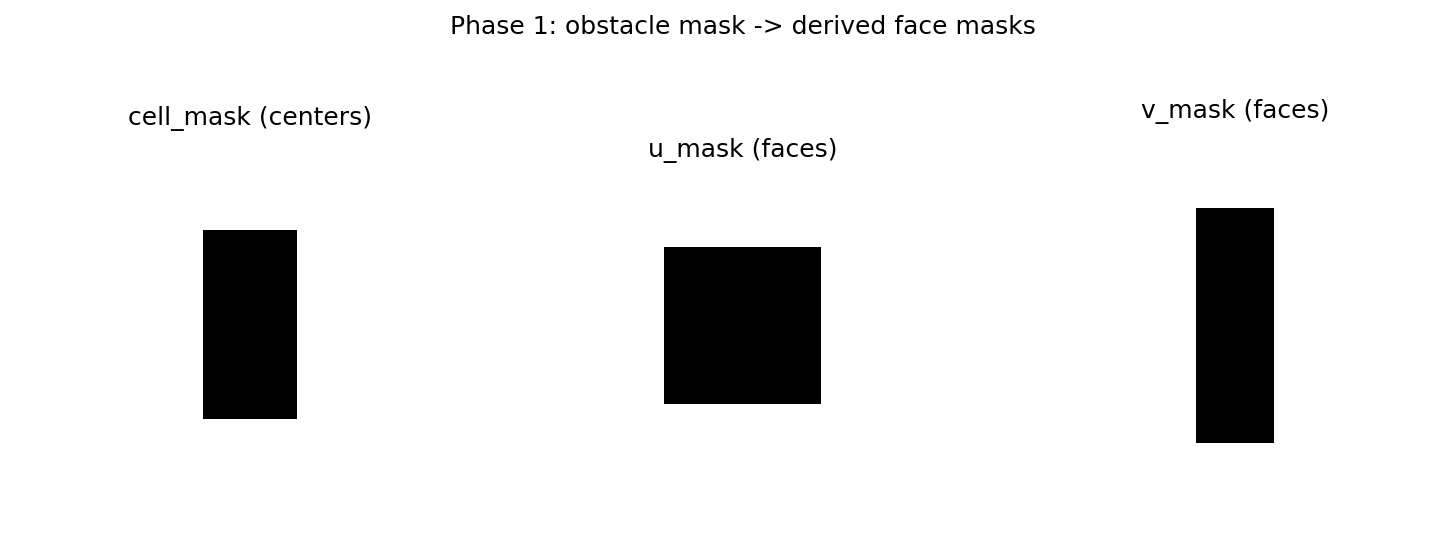

In [2]:
# Face masks derived from a small hand-drawn obstacle
cell_mask = np.ones((5, 4), dtype=bool)
cell_mask[2, 1:3] = False  # a 1x2 solid block in the interior
u_mask, v_mask = g.face_masks(cell_mask)

check("u_mask/v_mask shapes", u_mask.shape == (6, 4) and v_mask.shape == (5, 5))
check("u-face into/out of obstacle is blocked", not u_mask[2, 1] and not u_mask[3, 1])
check("u-face away from obstacle is open", u_mask[1, 0])
check("domain-edge u-face is open", u_mask[0, 0] and u_mask[-1, 0])
check("v-face into obstacle is blocked", not v_mask[2, 1])

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, arr, title in zip(axes, [cell_mask, u_mask, v_mask], ['cell_mask (centers)', 'u_mask (faces)', 'v_mask (faces)']):
    ax.imshow(arr.T, origin='lower', cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
fig.suptitle('Phase 1: obstacle mask -> derived face masks')
fig.tight_layout(rect=[0, 0, 1, 0.90])
save(fig, 'phase1_face_masks.png')

[PASS] Taylor-Green divergence ~ 0  max|div|=3.11e-14


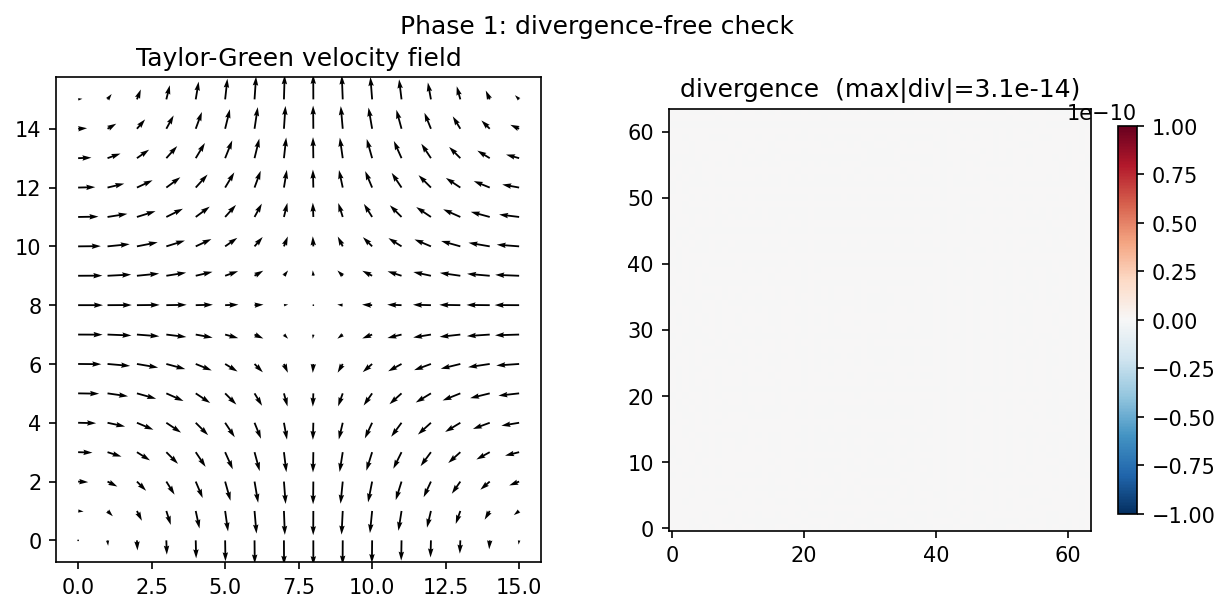

In [3]:
# Divergence of an analytic solenoidal field (Taylor-Green vortex):
#   u =  cos(pi x) sin(pi y),  v = -sin(pi x) cos(pi y)  is divergence-free
nx, ny, lx, ly = 64, 64, 1.0, 1.0
dx, dy = lx / nx, ly / ny

xu = np.arange(nx + 1) * dx
yu = (np.arange(ny) + 0.5) * dy
Xu, Yu = np.meshgrid(xu, yu, indexing='ij')
u_tg = np.cos(np.pi * Xu) * np.sin(np.pi * Yu)

xv = (np.arange(nx) + 0.5) * dx
yv = np.arange(ny + 1) * dy
Xv, Yv = np.meshgrid(xv, yv, indexing='ij')
v_tg = -np.sin(np.pi * Xv) * np.cos(np.pi * Yv)

div_tg = op.divergence(u_tg, v_tg, dx, dy)
check("Taylor-Green divergence ~ 0", np.max(np.abs(div_tg)) < 1e-10, f"max|div|={np.max(np.abs(div_tg)):.2e}")

uc, vc = g.velocity_at_centers(u_tg, v_tg)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
step = 4
axes[0].quiver(uc[::step, ::step].T, vc[::step, ::step].T)
axes[0].set_title('Taylor-Green velocity field')
axes[0].set_aspect('equal')
im = axes[1].imshow(div_tg.T, origin='lower', cmap='RdBu_r', vmin=-1e-10, vmax=1e-10)
axes[1].set_title(f'divergence  (max|div|={np.max(np.abs(div_tg)):.1e})')
plt.colorbar(im, ax=axes[1], shrink=0.8)
fig.suptitle('Phase 1: divergence-free check')
save(fig, 'phase1_divergence_free.png')

[PASS] quadratic field: interior Laplacian ~ 4  max err=1.8e-12
[PASS] Neumann-consistent field matches analytic Laplacian everywhere  max err=2.53e-03


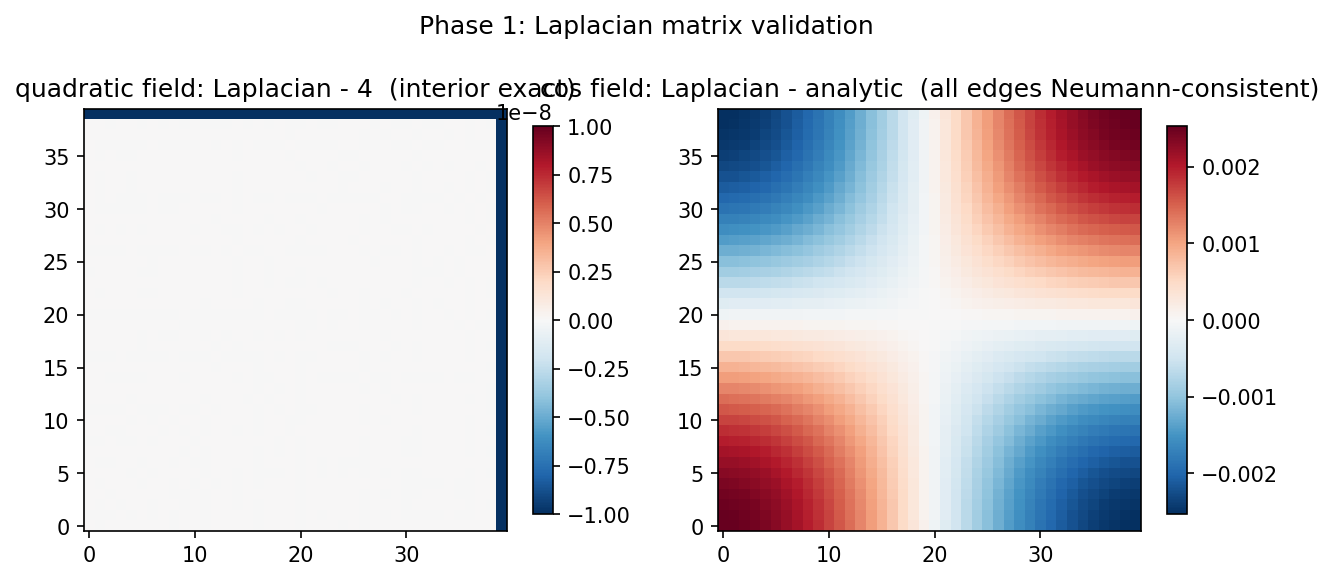

In [4]:
# Laplacian matrix vs known analytic fields
nx, ny, dxq, dyq = 40, 40, 0.05, 0.05
xc = (np.arange(nx) + 0.5) * dxq
yc = (np.arange(ny) + 0.5) * dyq
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')

# f = x^2 + y^2 -> analytic Laplacian = 4 everywhere
f_quad = Xc ** 2 + Yc ** 2
L, rhs = op.laplacian_matrix(nx, ny, dxq, dyq)
lap_quad = (L @ f_quad.ravel() + rhs.ravel()).reshape(nx, ny)
interior = lap_quad[3:-3, 3:-3]
check("quadratic field: interior Laplacian ~ 4", np.allclose(interior, 4.0, atol=1e-8),
      f"max err={np.max(np.abs(interior-4.0)):.1e}")

# f = cos(pi x)cos(pi y) satisfies zero-Neumann everywhere on a unit box,
# so the discrete Laplacian should match the analytic one even at the edge
lx = ly = nx * dxq
f_cos = np.cos(np.pi * Xc / lx) * np.cos(np.pi * Yc / ly)
lap_cos = (L @ f_cos.ravel() + rhs.ravel()).reshape(nx, ny)
analytic_cos = -np.pi ** 2 * (1 / lx ** 2 + 1 / ly ** 2) * f_cos
err_cos = lap_cos - analytic_cos
check("Neumann-consistent field matches analytic Laplacian everywhere",
      np.max(np.abs(err_cos)) < 0.05, f"max err={np.max(np.abs(err_cos)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axes[0].imshow((lap_quad - 4.0).T, origin='lower', cmap='RdBu_r', vmin=-1e-8, vmax=1e-8)
axes[0].set_title('quadratic field: Laplacian - 4  (interior exact)')
plt.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow(err_cos.T, origin='lower', cmap='RdBu_r')
axes[1].set_title('cos field: Laplacian - analytic  (all edges Neumann-consistent)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)
fig.suptitle('Phase 1: Laplacian matrix validation')
save(fig, 'phase1_laplacian_validation.png')

[PASS] obstacle Laplacian is symmetric  
[PASS] active-submatrix Laplacian is negative semi-definite  max eigenvalue=-1.8e-12
[PASS] Dirichlet edge: constant-B field has zero Laplacian  


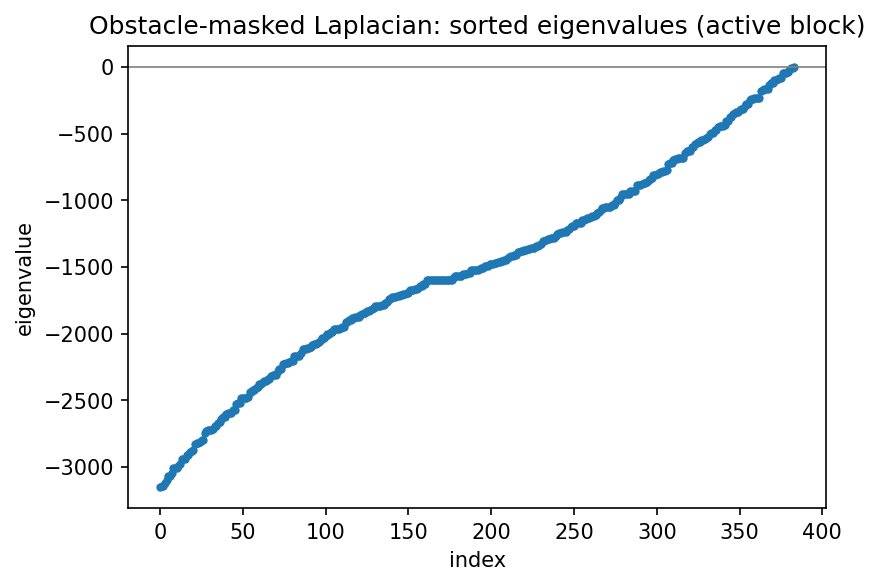

In [5]:
# Obstacle-masked Laplacian: symmetric, and negative semi-definite on its
# active submatrix (pinned obstacle-interior rows are a deliberate identity
# block for well-posedness, not part of the physical operator, so they're
# excluded from the definiteness check -- they contribute a +1 eigenvalue by
# design).
mask = np.ones((20, 20), dtype=bool)
mask[8:12, 8:12] = False
L_obs, rhs_obs = op.laplacian_matrix(20, 20, 0.05, 0.05, mask=mask)
check("obstacle Laplacian is symmetric", np.allclose((L_obs - L_obs.T).toarray(), 0.0))

active = mask.ravel()
eigvals_active = np.linalg.eigvalsh(L_obs.toarray()[np.ix_(active, active)])
check("active-submatrix Laplacian is negative semi-definite", np.max(eigvals_active) < 1e-8,
      f"max eigenvalue={np.max(eigvals_active):.1e}")

B = 3.0
L_dir, rhs_dir = op.laplacian_matrix(10, 10, 0.1, 0.1, bc={'right': ('dirichlet', B)})
lap_const = (L_dir @ np.full(100, B) + rhs_dir.ravel()).reshape(10, 10)
check("Dirichlet edge: constant-B field has zero Laplacian", np.allclose(lap_const, 0.0, atol=1e-10))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.sort(eigvals_active), '.')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Obstacle-masked Laplacian: sorted eigenvalues (active block)')
ax.set_xlabel('index')
ax.set_ylabel('eigenvalue')
save(fig, 'phase1_obstacle_laplacian_spectrum.png')

[PASS] interp_v_to_u exact in the interior  
[PASS] interp_v_to_u boundary error is the expected O(dx/2)  boundary err=0.500 (dx/2=0.500)


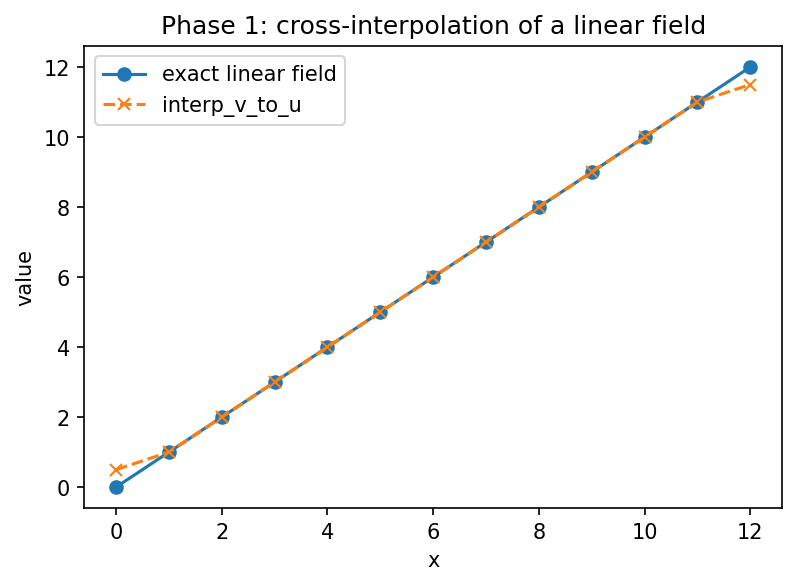

In [6]:
# Cross-interpolation: exact for a linear field in the interior; the two
# domain-edge columns fall back to a zeroth-order copy of the nearest
# v-sample (no second sample beyond the domain edge to average with),
# which is accurate only to O(dx/2) -- expected, and localized to the edge.
nx, ny = 12, 9
dxi = 1.0
xv = (np.arange(nx) + 0.5) * dxi
v_lin = np.broadcast_to(xv[:, None], (nx, ny + 1)).astype(float)
v_at_u = g.interp_v_to_u(v_lin)
xu = np.arange(nx + 1) * dxi
expected = np.broadcast_to(xu[:, None], (nx + 1, ny))

check("interp_v_to_u exact in the interior", np.allclose(v_at_u[1:-1], expected[1:-1]))
boundary_err = np.abs(v_at_u[[0, -1]] - expected[[0, -1]])
check("interp_v_to_u boundary error is the expected O(dx/2)", np.allclose(boundary_err, dxi / 2),
      f"boundary err={boundary_err.ravel()[0]:.3f} (dx/2={dxi/2:.3f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xu, expected[:, 0], 'o-', label='exact linear field')
ax.plot(xu, v_at_u[:, 0], 'x--', label='interp_v_to_u')
ax.set_xlabel('x'); ax.set_ylabel('value'); ax.legend()
ax.set_title('Phase 1: cross-interpolation of a linear field')
save(fig, 'phase1_interpolation.png')

[PASS] solid-body rotation vorticity ~ 2 everywhere  max err=0.0e+00


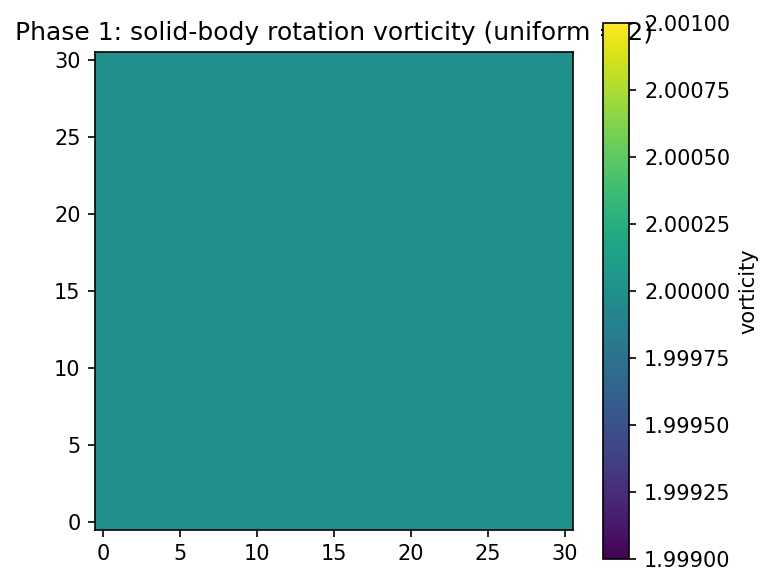

In [7]:
# Vorticity of solid-body rotation (u=-y, v=x) should be uniform = 2
nx, ny, lx, ly = 32, 32, 1.0, 1.0
dx, dy = lx / nx, ly / ny
xu = np.arange(nx + 1) * dx
yu = (np.arange(ny) + 0.5) * dy
Xu, Yu = np.meshgrid(xu, yu, indexing='ij')
u_rot = -(Yu - 0.5)
xv = (np.arange(nx) + 0.5) * dx
yv = np.arange(ny + 1) * dy
Xv, Yv = np.meshgrid(xv, yv, indexing='ij')
v_rot = (Xv - 0.5)
zeta = op.vorticity(u_rot, v_rot, dx, dy)
check("solid-body rotation vorticity ~ 2 everywhere", np.allclose(zeta, 2.0, atol=1e-10),
      f"max err={np.max(np.abs(zeta-2.0)):.1e}")

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(zeta.T, origin='lower', cmap='viridis', vmin=1.999, vmax=2.001)
cbar = plt.colorbar(im, ax=ax, label='vorticity')
cbar.formatter.set_useOffset(False)
cbar.update_ticks()
ax.set_title('Phase 1: solid-body rotation vorticity (uniform = 2)')
fig.tight_layout()
save(fig, 'phase1_vorticity_rotation.png')

## Phase 2 — Advection

In [8]:
import advection as adv

def gaussian(X, Y, cx, cy, L, sigma):
    # periodic-aware distance (shortest wrap-around separation)
    dx_ = (X - cx + L / 2) % L - L / 2
    dy_ = (Y - cy + L / 2) % L - L / 2
    return np.exp(-(dx_ ** 2 + dy_ ** 2) / (2 * sigma ** 2))

[PASS] uniform-flow blob keeps its shape (peak within 1%)  peak=0.9913 vs exact=0.9935
[PASS] convergence order ~2 under grid refinement  observed order=1.99


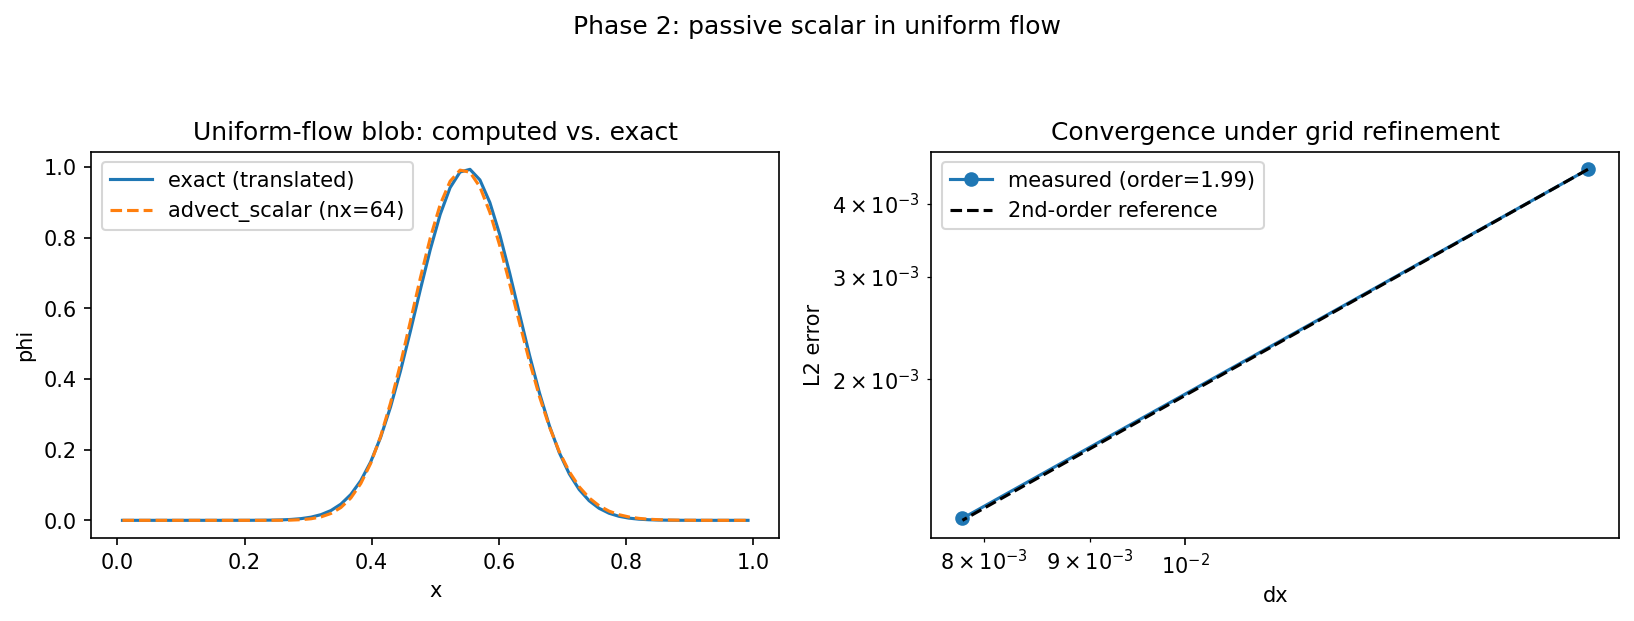

In [9]:
# Passive scalar in uniform flow: exactly linear transport (u is fixed, not
# self-evolving), so this isolates the convection scheme + RK3 integrator
# from momentum self-advection's Burgers-like nonlinearity, and gives a
# clean convergence-order measurement.
def run_uniform_advection(nx, ny, L, U0, T, sigma):
    dx = dy = L / nx
    xc = (np.arange(nx) + 0.5) * dx
    yc = (np.arange(ny) + 0.5) * dy
    Xc, Yc = np.meshgrid(xc, yc, indexing='ij')
    phi = gaussian(Xc, Yc, L / 4, L / 2, L, sigma)

    u = np.full((nx + 1, ny), U0)
    v = np.zeros((nx, ny + 1))

    dt = 0.4 * dx / U0
    nsteps = int(np.ceil(T / dt))
    dt = T / nsteps
    for _ in range(nsteps):
        phi = adv.advect_scalar(phi, u, v, dt, dx, dy)

    exact = gaussian(Xc, Yc, L / 4 + U0 * T, L / 2, L, sigma)
    err = np.sqrt(np.mean((phi - exact) ** 2))
    return err, phi, exact, Xc, Yc

L, U0, T, sigma = 1.0, 1.0, 0.3, 0.08
err64, phi64, exact64, X64, Y64 = run_uniform_advection(64, 64, L, U0, T, sigma)
err128, phi128, exact128, X128, Y128 = run_uniform_advection(128, 128, L, U0, T, sigma)
order = np.log2(err64 / err128)
check("uniform-flow blob keeps its shape (peak within 1%)",
      abs(phi64.max() - exact64.max()) / exact64.max() < 0.01,
      f"peak={phi64.max():.4f} vs exact={exact64.max():.4f}")
check("convergence order ~2 under grid refinement", 1.7 < order < 2.3, f"observed order={order:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
mid = 32
axes[0].plot(X64[:, mid], exact64[:, mid], '-', label='exact (translated)')
axes[0].plot(X64[:, mid], phi64[:, mid], '--', label='advect_scalar (nx=64)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('phi'); axes[0].legend()
axes[0].set_title('Uniform-flow blob: computed vs. exact')

axes[1].loglog([1 / 64, 1 / 128], [err64, err128], 'o-', label=f'measured (order={order:.2f})')
ref = err64 * np.array([1.0, 0.25])
axes[1].loglog([1 / 64, 1 / 128], ref, 'k--', label='2nd-order reference')
axes[1].set_xlabel('dx'); axes[1].set_ylabel('L2 error'); axes[1].legend()
axes[1].set_title('Convergence under grid refinement')
fig.suptitle('Phase 2: passive scalar in uniform flow')
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, 'phase2_uniform_flow_convergence.png')

[PASS] rigid rotation: blob returns after one period  L2 error=1.795e-02
[PASS] rigid rotation: peak amplitude retained (<5% loss)  peak before=0.9935, after=0.9809


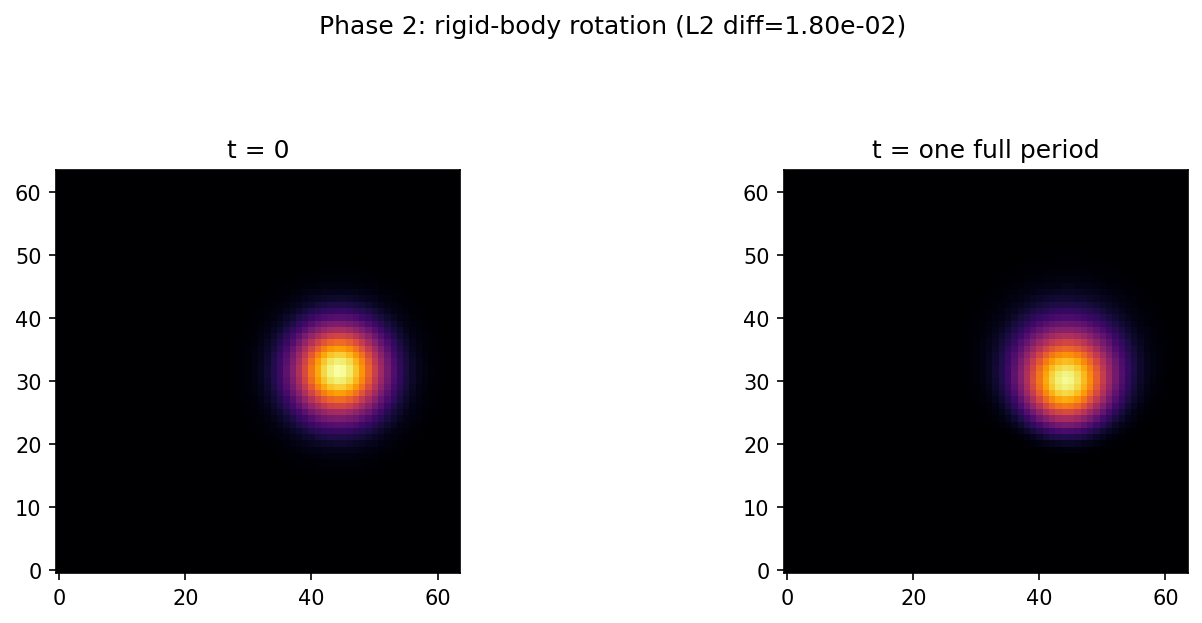

In [10]:
# Rigid-body rotation: a blob carried by a fixed solid-body-rotation
# velocity field should return close to its starting position/shape after
# exactly one rotation period (shape-preserving in the continuum; only
# numerical diffusion should shrink/spread it here).
def run_rigid_rotation(nx, ny, L, omega, sigma):
    dx = dy = L / nx
    xc = (np.arange(nx) + 0.5) * dx
    yc = (np.arange(ny) + 0.5) * dy
    Xc, Yc = np.meshgrid(xc, yc, indexing='ij')
    cx0, cy0 = 0.7 * L, 0.5 * L
    phi0 = gaussian(Xc, Yc, cx0, cy0, L, sigma)
    phi = phi0.copy()

    xu, yu = np.arange(nx + 1) * dx, (np.arange(ny) + 0.5) * dy
    Xu, Yu = np.meshgrid(xu, yu, indexing='ij')
    u = -omega * (Yu - L / 2)
    xv, yv = (np.arange(nx) + 0.5) * dx, np.arange(ny + 1) * dy
    Xv, Yv = np.meshgrid(xv, yv, indexing='ij')
    v = omega * (Xv - L / 2)

    speed_max = omega * (L / 2) * np.sqrt(2)
    dt = 0.3 * dx / speed_max
    T = 2 * np.pi / omega
    nsteps = int(np.ceil(T / dt))
    dt = T / nsteps
    for _ in range(nsteps):
        phi = adv.advect_scalar(phi, u, v, dt, dx, dy)
    return phi0, phi, Xc, Yc

phi0_rot, phi_rot, Xr, Yr = run_rigid_rotation(64, 64, 1.0, 2 * np.pi, 0.08)
err_rot = np.sqrt(np.mean((phi_rot - phi0_rot) ** 2))
check("rigid rotation: blob returns after one period", err_rot < 0.03, f"L2 error={err_rot:.3e}")
check("rigid rotation: peak amplitude retained (<5% loss)",
      (phi0_rot.max() - phi_rot.max()) / phi0_rot.max() < 0.05,
      f"peak before={phi0_rot.max():.4f}, after={phi_rot.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].imshow(phi0_rot.T, origin='lower', cmap='inferno', vmin=0, vmax=1)
axes[0].set_title('t = 0')
axes[1].imshow(phi_rot.T, origin='lower', cmap='inferno', vmin=0, vmax=1)
axes[1].set_title('t = one full period')
fig.suptitle(f'Phase 2: rigid-body rotation (L2 diff={err_rot:.2e})')
fig.tight_layout(rect=[0, 0, 1, 0.90])
save(fig, 'phase2_rigid_rotation.png')

[PASS] momentum self-advection stays finite  
[PASS] momentum self-advection matches linear-regime prediction  L2 error=1.968e-03
[PASS] no spurious v generated from a purely-x perturbation  max|v|=0.0e+00


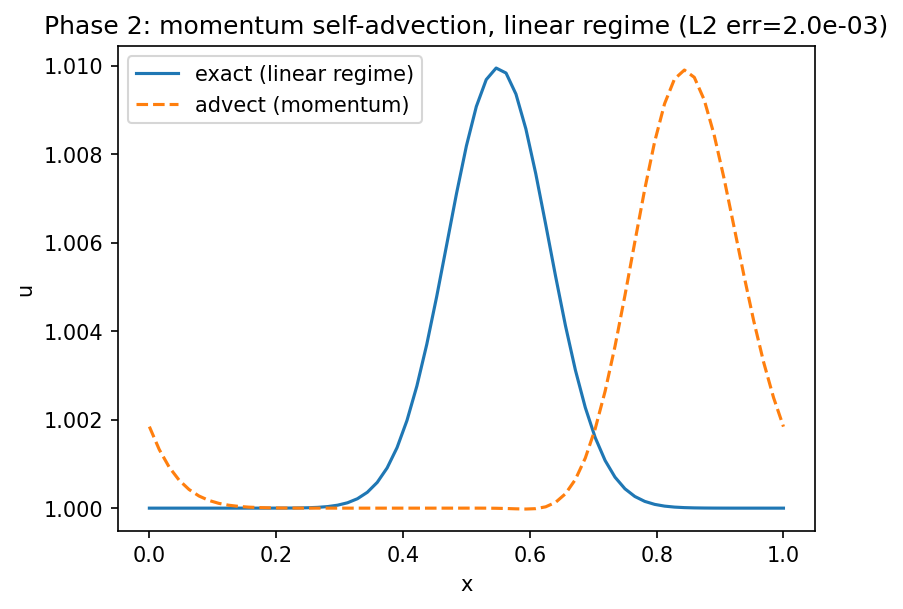

In [11]:
# Momentum self-advection (the actual convective_tendency/advect used by
# the real solver): small-amplitude perturbation on a uniform background so
# the nonlinear self-advection term is in its linear regime, where the exact
# answer is just translation at the background speed -- checks the real
# momentum operator, not just the scalar-tracer stand-in above, is stable
# and quantitatively correct.
def run_momentum(nx, ny, L, U0, eps, T, sigma):
    dx = dy = L / nx
    xu, yu = np.arange(nx + 1) * dx, (np.arange(ny) + 0.5) * dy
    Xu, Yu = np.meshgrid(xu, yu, indexing='ij')
    u = U0 + eps * gaussian(Xu, Yu, L / 4, L / 2, L, sigma)
    v = np.zeros((nx, ny + 1))

    dt = 0.4 * dx / (U0 + eps)
    nsteps = int(np.ceil(T / dt))
    dt = T / nsteps
    for _ in range(nsteps):
        u, v = adv.advect(u, v, dt, dx, dy)
    exact = U0 + eps * gaussian(Xu, Yu, L / 4 + U0 * T, L / 2, L, sigma)
    return u, v, exact, Xu

u_mom, v_mom, exact_mom, Xu_mom = run_momentum(64, 64, 1.0, 1.0, 0.01, 0.3, 0.08)
err_mom = np.sqrt(np.mean((u_mom - exact_mom) ** 2))
check("momentum self-advection stays finite", np.isfinite(u_mom).all() and np.isfinite(v_mom).all())
check("momentum self-advection matches linear-regime prediction", err_mom < 5e-3, f"L2 error={err_mom:.3e}")
check("no spurious v generated from a purely-x perturbation", np.max(np.abs(v_mom)) < 1e-10,
      f"max|v|={np.max(np.abs(v_mom)):.1e}")

fig, ax = plt.subplots(figsize=(6, 4.2))
mid = 32
ax.plot(Xu_mom[:, mid], exact_mom[:, mid], '-', label='exact (linear regime)')
ax.plot(Xu_mom[:, mid], u_mom[:, mid], '--', label='advect (momentum)')
ax.set_xlabel('x'); ax.set_ylabel('u'); ax.legend()
ax.set_title(f'Phase 2: momentum self-advection, linear regime (L2 err={err_mom:.1e})')
save(fig, 'phase2_momentum_advection.png')

## Phase 3 — Diffusion

[PASS] sinusoidal decay matches the fully-discrete exact solution  max err=5.95e-12
[PASS] sinusoidal decay approaches the continuum e^(-nu k^2 t) rate  relative err=2.93e-04 (~O(dx^2)=6.3e-04)
[PASS] y-uniformity preserved (tangential Neumann is a no-op here)  


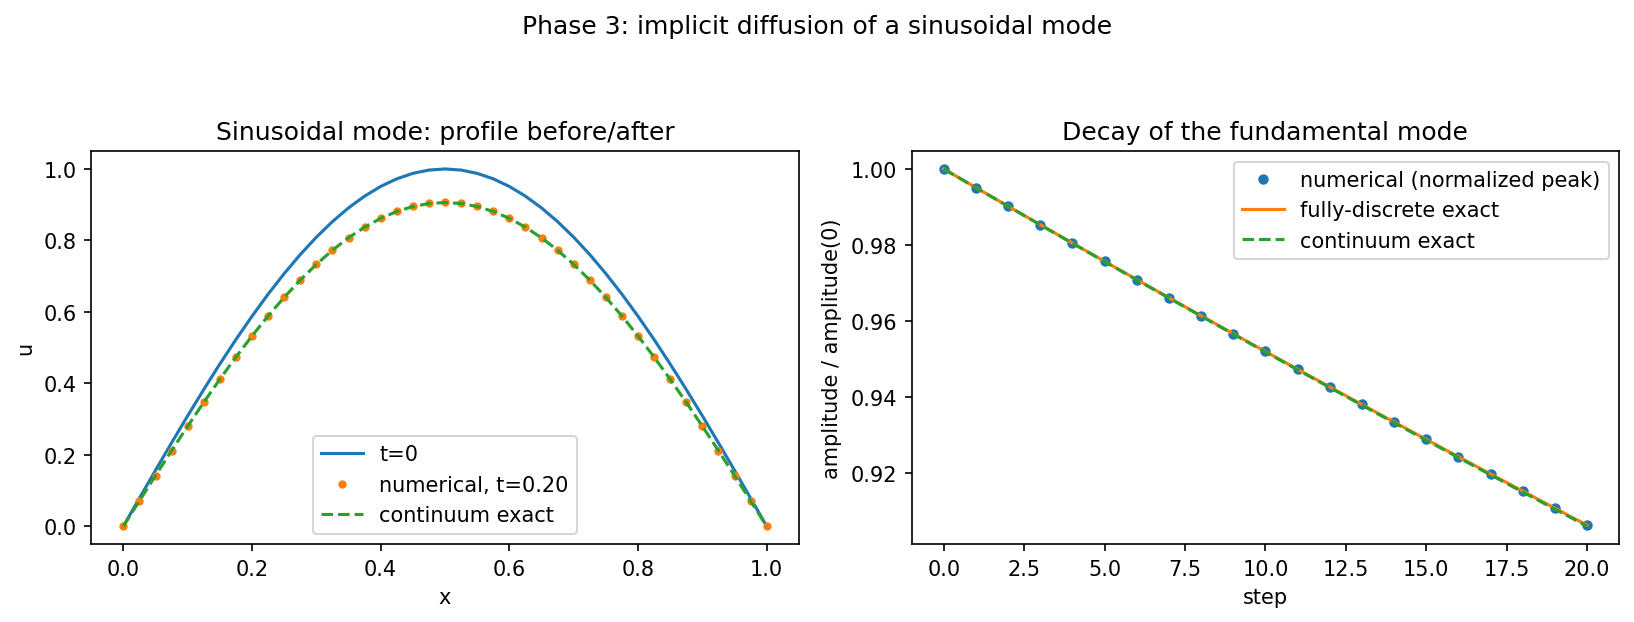

In [12]:
import diffusion as diff

# Sinusoidal decay for u-component diffusion.
#   u(x,y,0) = sin(pi x / Lx), uniform in y
#   normal (x) BC: dirichlet_exact = 0 at both walls (u=0 there exactly,
#     matching sin(0)=sin(pi)=0 -- no discretization mismatch)
#   tangential (y) BC: neumann (zero-gradient) -- consistent with a
#     y-uniform field, so the y-direction contributes nothing
nx, ny, Lx, Ly = 40, 8, 1.0, 0.2
dx, dy = Lx / nx, Ly / ny
nu = 0.05
dt = 0.01
nsteps = 20

xu = np.arange(nx + 1) * dx
u0 = np.sin(np.pi * xu / Lx)
u = np.broadcast_to(u0[:, None], (nx + 1, ny)).copy()
mask = np.ones((nx + 1, ny), dtype=bool)

# fully-discrete exact decay factor per step (backward Euler + the exact
# discrete eigenvalue of the Dirichlet finite-difference Laplacian for the
# fundamental mode) -- checks the solve itself, with no space/time
# truncation error of its own to blur the comparison.
lam_discrete = -(4 / dx ** 2) * np.sin(np.pi / (2 * nx)) ** 2
decay_per_step = 1.0 / (1 - dt * nu * lam_discrete)

u_diff_op = diff.build_diffusion_operator(mask, dx, dy, normal_axis=0,
                                           normal_bc=(0.0, 0.0), tangential_bc=('neumann', 'neumann'))
u_num = u.copy()
peak_history = [1.0]
for step in range(nsteps):
    u_num = diff.diffuse_component(u_num, u_diff_op, dt, nu, x0=u_num)
    peak_history.append(u_num[:, 0].max() / u0.max())

exact_discrete = u0 * decay_per_step ** nsteps
err_discrete = np.max(np.abs(u_num[:, 0] - exact_discrete))
check("sinusoidal decay matches the fully-discrete exact solution", err_discrete < 1e-8,
      f"max err={err_discrete:.2e}")

t_final = nsteps * dt
exact_continuum_final = u0 * np.exp(-nu * (np.pi / Lx) ** 2 * t_final)
rel_err_continuum = (np.max(np.abs(u_num[:, 0] - exact_continuum_final)) / np.max(np.abs(exact_continuum_final)))
check("sinusoidal decay approaches the continuum e^(-nu k^2 t) rate", rel_err_continuum < 1e-2,
      f"relative err={rel_err_continuum:.2e} (~O(dx^2)={dx**2:.1e})")
check("y-uniformity preserved (tangential Neumann is a no-op here)", np.allclose(u_num, u_num[:, :1]))

steps_arr = np.arange(nsteps + 1)
continuum_curve = np.exp(-nu * (np.pi / Lx) ** 2 * steps_arr * dt)
discrete_curve = decay_per_step ** steps_arr

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(xu, u0, label='t=0')
axes[0].plot(xu, u_num[:, 0], 'o', markersize=3, label=f'numerical, t={t_final:.2f}')
axes[0].plot(xu, exact_continuum_final, '--', label='continuum exact')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u'); axes[0].legend()
axes[0].set_title('Sinusoidal mode: profile before/after')

axes[1].plot(steps_arr, peak_history, 'o', markersize=4, label='numerical (normalized peak)')
axes[1].plot(steps_arr, discrete_curve, '-', label='fully-discrete exact')
axes[1].plot(steps_arr, continuum_curve, '--', label='continuum exact')
axes[1].set_xlabel('step'); axes[1].set_ylabel('amplitude / amplitude(0)'); axes[1].legend()
axes[1].set_title('Decay of the fundamental mode')
fig.suptitle('Phase 3: implicit diffusion of a sinusoidal mode')
fig.tight_layout(rect=[0, 0, 1, 0.93])
save(fig, 'phase3_sinusoidal_decay.png')

[PASS] v-component diffusion (axis-swapped) matches fully-discrete exact  max err=4.94e-12
[PASS] x-uniformity preserved for v  
[PASS] no-flow, no-forcing state stays exactly at rest  max|u| after 50 steps=0.0e+00
[PASS] obstacle-masked diffusion stays finite  
[PASS] obstacle-blocked faces report exactly 0  


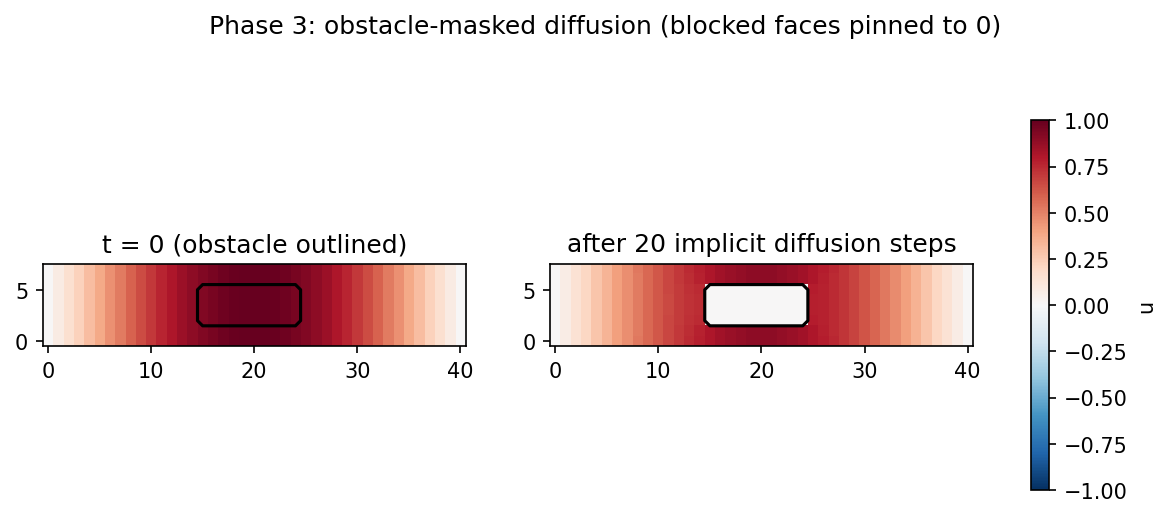

In [13]:
# Same test transposed onto v (normal_axis=1) -- exercises the axis-swap
# branch used for v-diffusion in the real solver.
nx2, ny2, Lx2, Ly2 = 8, 40, 0.2, 1.0
dx2, dy2 = Lx2 / nx2, Ly2 / ny2
yv = np.arange(ny2 + 1) * dy2
v0 = np.sin(np.pi * yv / Ly2)
v = np.broadcast_to(v0[None, :], (nx2, ny2 + 1)).copy()
vmask = np.ones((nx2, ny2 + 1), dtype=bool)

v_diff_op = diff.build_diffusion_operator(vmask, dx2, dy2, normal_axis=1,
                                           normal_bc=(0.0, 0.0), tangential_bc=('neumann', 'neumann'))
v_num = v.copy()
for step in range(nsteps):
    v_num = diff.diffuse_component(v_num, v_diff_op, dt, nu, x0=v_num)

lam_discrete_v = -(4 / dy2 ** 2) * np.sin(np.pi / (2 * ny2)) ** 2
decay_per_step_v = 1.0 / (1 - dt * nu * lam_discrete_v)
exact_discrete_v = v0 * decay_per_step_v ** nsteps
err_v = np.max(np.abs(v_num[0, :] - exact_discrete_v))
check("v-component diffusion (axis-swapped) matches fully-discrete exact", err_v < 1e-8, f"max err={err_v:.2e}")
check("x-uniformity preserved for v", np.allclose(v_num, v_num[:1, :]))

# No-flow, no-forcing steady state stays exactly at rest.
u_rest_diff_op = diff.build_diffusion_operator(mask, dx, dy, normal_axis=0,
                                                normal_bc=(0.0, 0.0), tangential_bc=(0.0, 0.0))
u_rest = np.zeros((nx + 1, ny))
for step in range(50):
    u_rest = diff.diffuse_component(u_rest, u_rest_diff_op, dt, nu, x0=u_rest)
check("no-flow, no-forcing state stays exactly at rest", np.max(np.abs(u_rest)) < 1e-12,
      f"max|u| after 50 steps={np.max(np.abs(u_rest)):.1e}")

# Obstacle-masked diffusion: stable, and blocked faces report exactly 0.
mask_obs = np.ones((nx + 1, ny), dtype=bool)
mask_obs[15:25, 2:6] = False
u_obs_diff_op = diff.build_diffusion_operator(mask_obs, dx, dy, normal_axis=0,
                                               normal_bc=(0.0, 0.0), tangential_bc=('neumann', 'neumann'))
u_obs = np.broadcast_to(u0[:, None], (nx + 1, ny)).copy()
u_before = u_obs.copy()
for step in range(nsteps):
    u_obs = diff.diffuse_component(u_obs, u_obs_diff_op, dt, nu, x0=u_obs)
check("obstacle-masked diffusion stays finite", np.isfinite(u_obs).all())
check("obstacle-blocked faces report exactly 0", np.allclose(u_obs[~mask_obs], 0.0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(u_before.T, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('t = 0 (obstacle outlined)')
im1 = axes[1].imshow(u_obs.T, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title(f'after {nsteps} implicit diffusion steps')
for ax in axes:
    ax.contour((~mask_obs).T, levels=[0.5], colors='k', linewidths=1.5)
plt.colorbar(im1, ax=axes, shrink=0.8, label='u')
fig.suptitle('Phase 3: obstacle-masked diffusion (blocked faces pinned to 0)')
save(fig, 'phase3_obstacle_diffusion.png')

## Phase 4 — Pressure projection

[PASS] closed-cavity Poisson solve recovers the analytic field  max err=7.13e-04 (~O(dx^2)=4.3e-04)
[PASS] outflow-domain Poisson solve recovers the analytic field exactly (no offset)  max err=3.03e-04


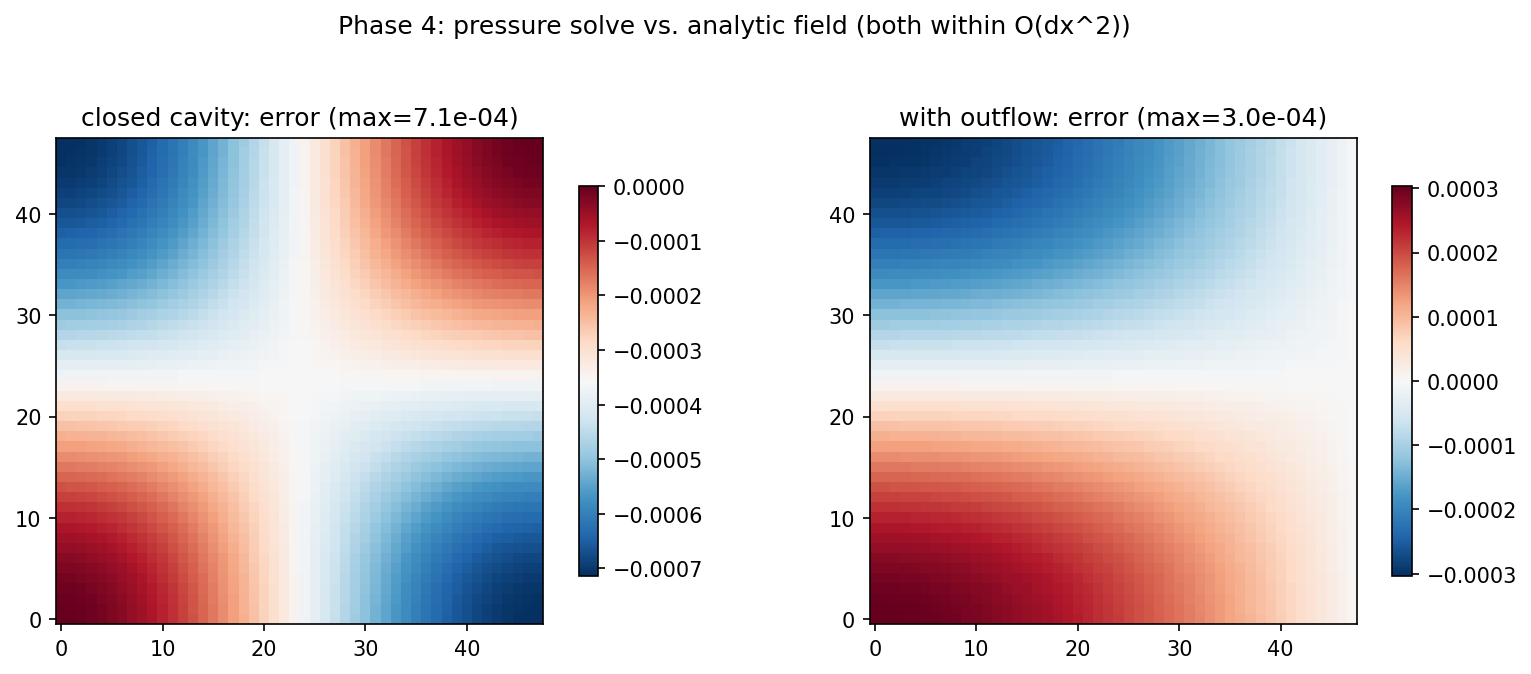

In [14]:
import pressure as pr

nx, ny, Lx, Ly = 48, 48, 1.0, 1.0
dx, dy = Lx / nx, Ly / ny
xc = (np.arange(nx) + 0.5) * dx
yc = (np.arange(ny) + 0.5) * dy
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')
mask_p = np.ones((nx, ny), dtype=bool)

# Analytic RHS recovery, singular (all-Neumann, closed-cavity) case: a field
# satisfying zero-Neumann everywhere, so the discrete solve should recover
# it exactly up to the additive constant fixed by the pin.
p_exact = np.cos(np.pi * Xc / Lx) * np.cos(np.pi * Yc / Ly)
lap_exact = -np.pi ** 2 * (1 / Lx ** 2 + 1 / Ly ** 2) * p_exact

system_closed = pr.build_pressure_system(mask_p, dx, dy, outflow_edges=())
p_singular = pr.solve_pressure(system_closed, lap_exact)
p_exact_shifted = p_exact - p_exact.ravel()[system_closed.pin_index]
err_singular = np.max(np.abs(p_singular - p_exact_shifted))
check("closed-cavity Poisson solve recovers the analytic field", err_singular < 5e-3,
      f"max err={err_singular:.2e} (~O(dx^2)={dx**2:.1e})")

# Analytic RHS recovery, non-singular case: one outflow edge (Dirichlet p=0)
# removes the null space, so this field is recovered with no offset ambiguity.
p_exact2 = np.cos(np.pi * Xc / (2 * Lx)) * np.cos(np.pi * Yc / Ly)
lap_exact2 = -(np.pi / (2 * Lx)) ** 2 * p_exact2 - (np.pi / Ly) ** 2 * p_exact2

system_open = pr.build_pressure_system(mask_p, dx, dy, outflow_edges=('right',))
p_outflow = pr.solve_pressure(system_open, lap_exact2)
err_outflow = np.max(np.abs(p_outflow - p_exact2))
check("outflow-domain Poisson solve recovers the analytic field exactly (no offset)",
      err_outflow < 5e-3, f"max err={err_outflow:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
im0 = axes[0].imshow((p_singular - p_exact_shifted).T, origin='lower', cmap='RdBu_r')
axes[0].set_title(f'closed cavity: error (max={err_singular:.1e})')
plt.colorbar(im0, ax=axes[0], shrink=0.8)
im1 = axes[1].imshow((p_outflow - p_exact2).T, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'with outflow: error (max={err_outflow:.1e})')
plt.colorbar(im1, ax=axes[1], shrink=0.8)
fig.suptitle('Phase 4: pressure solve vs. analytic field (both within O(dx^2))')
fig.tight_layout(rect=[0, 0, 1, 0.92])
save(fig, 'phase4_analytic_recovery.png')

[PASS] projecting a noisy field drives max|div| to ~machine precision  before=3.66e+02, after=3.80e-12
[PASS] closed-cavity compatibility condition holds for a zero-boundary field  sum(div)*dx*dy=9.87e-17
[PASS] closed-cavity projection of a compatible field also reaches ~machine precision  max|div| after=4.00e-11


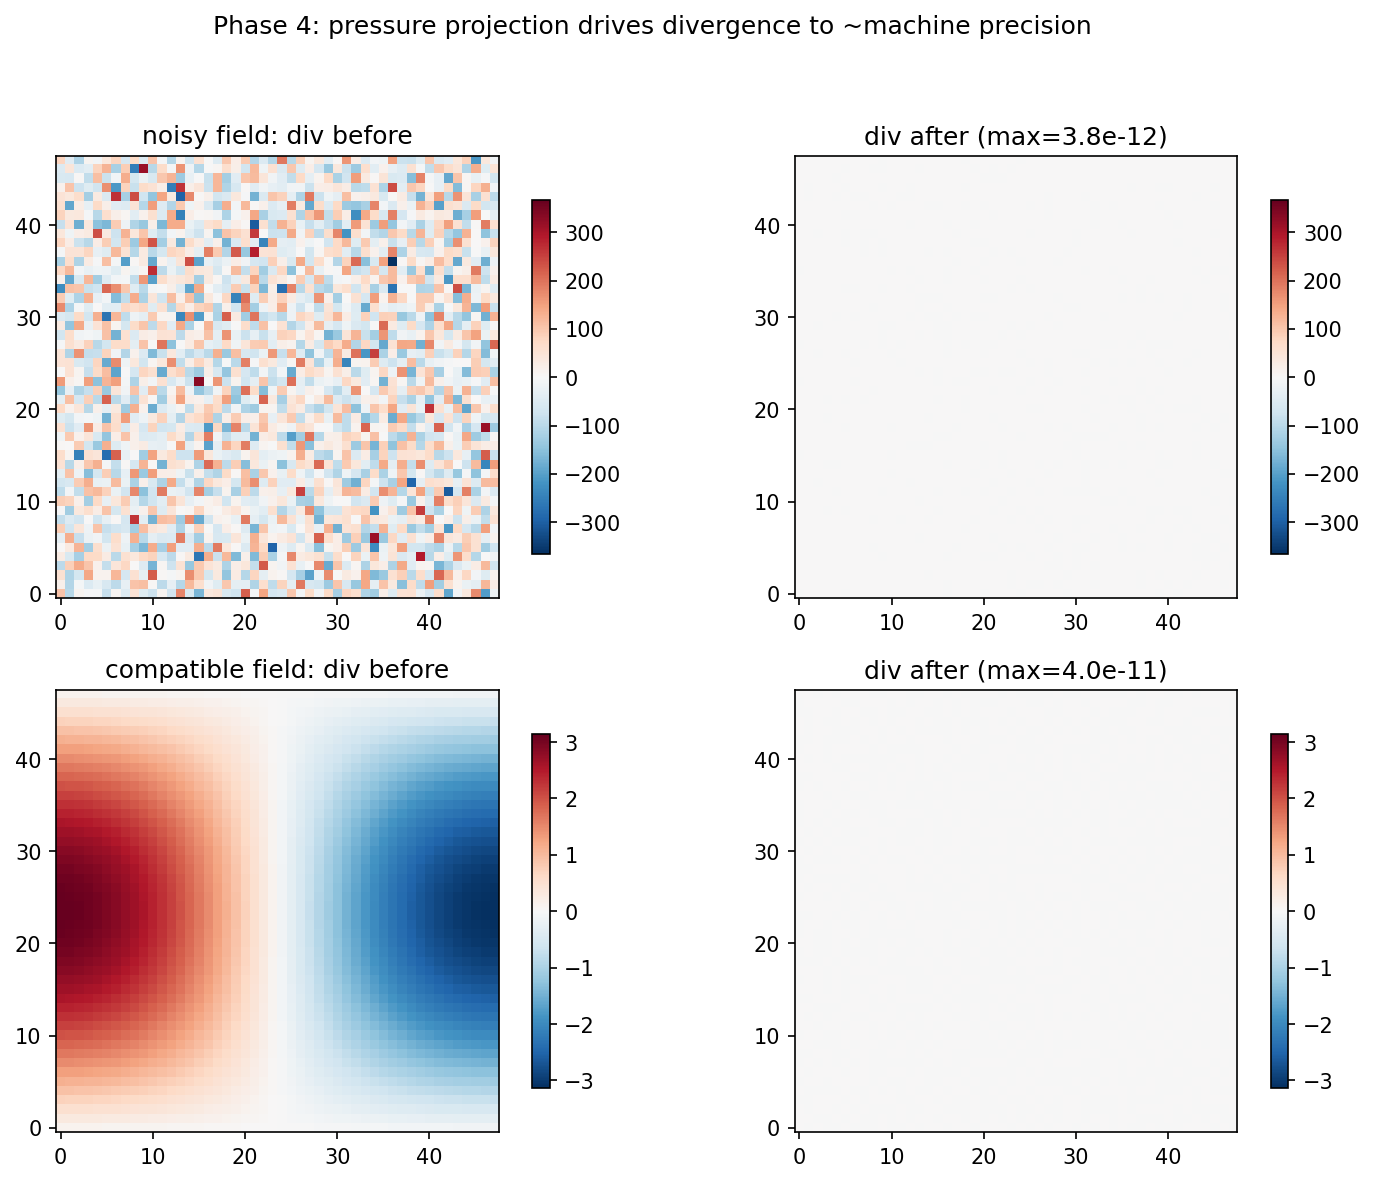

In [15]:
# Projecting a divergent field drives divergence to near machine precision.
# gradient() only corrects *interior* faces (boundary faces are set by
# boundary conditions, not by the pressure solve), so a fair test needs
# boundary faces already at a physically consistent value -- zero (no-slip,
# closed box) is the simplest such case, and also trivially satisfies the
# closed system's compatibility condition regardless of the random interior.
rng = np.random.default_rng(0)
u_rand = rng.normal(size=(nx + 1, ny))
v_rand = rng.normal(size=(nx, ny + 1))
u_rand[[0, -1], :] = 0.0
v_rand[:, [0, -1]] = 0.0
div_rand_before = op.divergence(u_rand, v_rand, dx, dy)
u_p1, v_p1, _, max_div_rand_after = pr.project_velocity(u_rand, v_rand, system_closed, dt=0.01, rho=1.0)
div_rand_after = op.divergence(u_p1, v_p1, dx, dy)
check("projecting a noisy field drives max|div| to ~machine precision",
      max_div_rand_after < 1e-8, f"before={np.max(np.abs(div_rand_before)):.2e}, after={max_div_rand_after:.2e}")

# Closed-cavity compatibility: a field vanishing on the entire boundary has
# zero net boundary flux by construction, so sum(div(u*)) ~ 0 -- the
# condition required for a closed (all-Neumann) system to be solvable at all.
xu = np.arange(nx + 1) * dx
yu = (np.arange(ny) + 0.5) * dy
Xu, Yu = np.meshgrid(xu, yu, indexing='ij')
u_zero_bc = np.sin(np.pi * Xu / Lx) * np.sin(np.pi * Yu / Ly)
v_zero_bc = np.zeros((nx, ny + 1))
div_compat_before = op.divergence(u_zero_bc, v_zero_bc, dx, dy)
compat = np.sum(div_compat_before) * dx * dy
check("closed-cavity compatibility condition holds for a zero-boundary field",
      abs(compat) < 1e-10, f"sum(div)*dx*dy={compat:.2e}")

u_p2, v_p2, _, max_div_compat_after = pr.project_velocity(u_zero_bc, v_zero_bc, system_closed, dt=0.01, rho=1.0)
div_compat_after = op.divergence(u_p2, v_p2, dx, dy)
check("closed-cavity projection of a compatible field also reaches ~machine precision",
      max_div_compat_after < 1e-8, f"max|div| after={max_div_compat_after:.2e}")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, arr, title, vmax in [
    (axes[0, 0], div_rand_before, 'noisy field: div before', np.max(np.abs(div_rand_before))),
    (axes[0, 1], div_rand_after, f'div after (max={max_div_rand_after:.1e})', np.max(np.abs(div_rand_before))),
    (axes[1, 0], div_compat_before, 'compatible field: div before', np.max(np.abs(div_compat_before))),
    (axes[1, 1], div_compat_after, f'div after (max={max_div_compat_after:.1e})', np.max(np.abs(div_compat_before))),
]:
    im = ax.imshow(arr.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('Phase 4: pressure projection drives divergence to ~machine precision')
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, 'phase4_projection.png')

[PASS] pinning a different reference cell shifts the solution by a pure constant  std of (p_a - p_b)=1.70e-14, mean offset=-1.0312


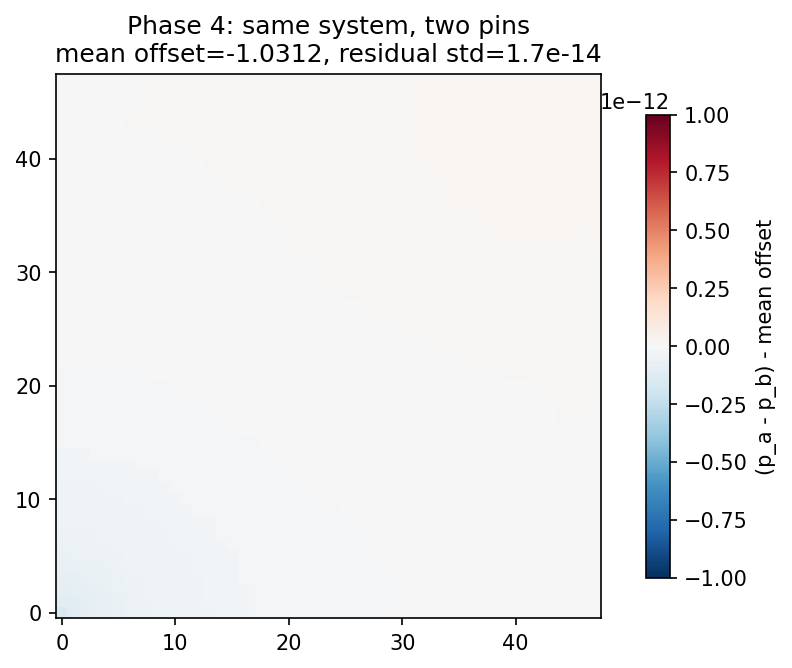

In [16]:
# Null-space handling: pinning a *different* reference cell should give a
# pressure field that differs from the first only by a constant additive
# offset -- the one degree of freedom a pure-Neumann system can't fix.
system_closed_alt = pr.build_pressure_system(mask_p, dx, dy, outflow_edges=(), pin_index=nx * ny // 2 + 3)
p_a = pr.solve_pressure(system_closed, lap_exact)
p_b = pr.solve_pressure(system_closed_alt, lap_exact)
offset_std = np.std(p_a - p_b)
check("pinning a different reference cell shifts the solution by a pure constant",
      offset_std < 1e-8, f"std of (p_a - p_b)={offset_std:.2e}, mean offset={np.mean(p_a - p_b):.4f}")

# Center on the mean offset before plotting: (p_a - p_b) is the constant
# mean_offset plus ~1e-14 noise, and letting matplotlib auto-scale a
# colorbar to an absolute range around that constant produces a confusing
# offset-notation label (as seen debugging Simple_Fluid's vorticity plot
# earlier) rather than showing the actually-relevant tiny residual.
residual = (p_a - p_b) - np.mean(p_a - p_b)
fig, ax = plt.subplots(figsize=(6.5, 4.6))
im = ax.imshow(residual.T, origin='lower', cmap='RdBu_r', vmin=-1e-12, vmax=1e-12)
cbar = plt.colorbar(im, ax=ax, label='(p_a - p_b) - mean offset', shrink=0.85)
cbar.formatter.set_useOffset(False)
cbar.update_ticks()
ax.set_title(f'Phase 4: same system, two pins\nmean offset={np.mean(p_a - p_b):.4f}, residual std={offset_std:.1e}')
fig.tight_layout()
save(fig, 'phase4_pin_independence.png')

## Phase 5 — Boundary conditions & solver assembly

[PASS] no-obstacle, zero-forcing box stays at rest  max speed over 100 steps=0.0e+00

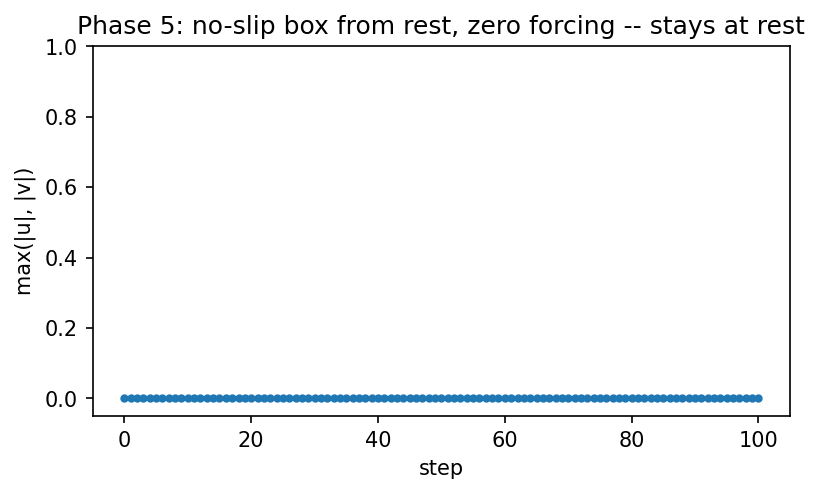

In [17]:
import grid as g
import boundary as bnd
import solver as sv

# No-obstacle box, all no-slip walls, zero forcing -> stays at rest
# indefinitely (regression test for BC/mask wiring bugs).
nx_r, ny_r, Lx_r, Ly_r = 20, 20, 1.0, 1.0
grid_rest = g.make_grid(nx_r, ny_r, Lx_r, Ly_r)
bc_rest = {'left': {'type': 'no_slip'}, 'right': {'type': 'no_slip'},
           'bottom': {'type': 'no_slip'}, 'top': {'type': 'no_slip'}}
system_rest = sv.build_system(grid_rest, bc_rest)

u_r = np.zeros((nx_r + 1, ny_r))
v_r = np.zeros((nx_r, ny_r + 1))
nu_r, dt_r = 0.1, 0.01
speed_history = [0.0]
for step in range(100):
    u_r, v_r, p_r, max_div_r = sv.step(u_r, v_r, grid_rest, bc_rest, system_rest, dt_r, nu_r)
    speed_history.append(max(np.max(np.abs(u_r)), np.max(np.abs(v_r))))

check("no-obstacle, zero-forcing box stays at rest", max(speed_history) < 1e-12,
      f"max speed over 100 steps={max(speed_history):.1e}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(speed_history, '.-')
ax.set_ylim(-0.05, 1.0)
ax.set_xlabel('step'); ax.set_ylabel('max(|u|, |v|)')
ax.set_title('Phase 5: no-slip box from rest, zero forcing -- stays at rest')
save(fig, 'phase5_at_rest.png')

[PASS] channel flow projection stays near machine precision  max|div| at final step=4.01e-14
[PASS] developed channel profile matches analytic Poiseuille  relative L2 error=0.0021, measured peak=1.4946, analytic peak=1.5000


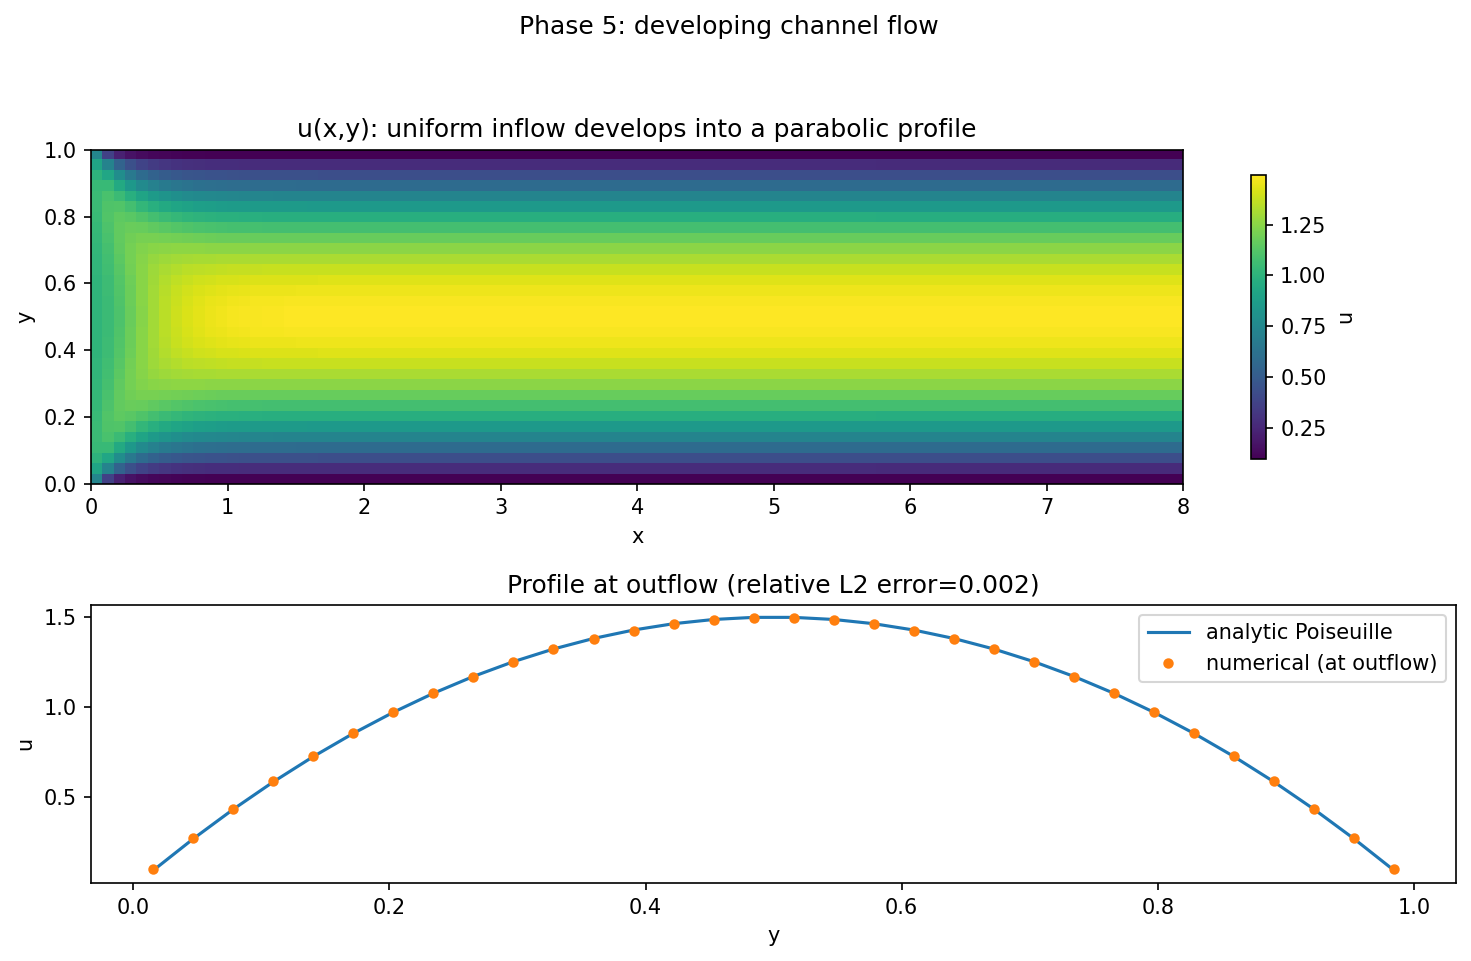

In [18]:
# Developing channel flow (inflow -> outflow, no-slip top/bottom) should
# relax to the analytic parabolic Poiseuille profile well before the
# outflow -- a full-pipeline check with advection+diffusion+pressure+BCs
# all genuinely participating, independent of any single-phase test above.
H, L = 1.0, 8.0
Re, U_in = 20.0, 1.0
nu_channel = U_in * H / Re

nx_c, ny_c = 96, 32
grid_c = g.make_grid(nx_c, ny_c, L, H)
bc_c = {'left': {'type': 'inflow', 'value': U_in}, 'right': {'type': 'outflow'},
        'bottom': {'type': 'no_slip'}, 'top': {'type': 'no_slip'}}
system_c = sv.build_system(grid_c, bc_c)

u_c = np.full((nx_c + 1, ny_c), U_in)
v_c = np.zeros((nx_c, ny_c + 1))
u_c[:, 0] = 0.0
u_c[:, -1] = 0.0

t_final = 15.0
dt_c = sv.cfl_timestep(u_c, v_c, grid_c.dx, grid_c.dy, cfl_number=0.4)
nsteps = int(np.ceil(t_final / dt_c))
for step in range(nsteps):
    dt_c = sv.cfl_timestep(u_c, v_c, grid_c.dx, grid_c.dy, cfl_number=0.4)
    u_c, v_c, p_c, max_div_c = sv.step(u_c, v_c, grid_c, bc_c, system_c, dt_c, nu_channel)

check("channel flow projection stays near machine precision", max_div_c < 1e-8,
      f"max|div| at final step={max_div_c:.2e}")

yc = (np.arange(ny_c) + 0.5) * grid_c.dy
u_outflow_profile = 0.5 * (u_c[-2, :] + u_c[-1, :])
u_max_analytic = 1.5 * U_in
u_analytic = u_max_analytic * (1 - ((yc - H / 2) / (H / 2)) ** 2)
rel_err = np.sqrt(np.mean((u_outflow_profile - u_analytic) ** 2)) / u_max_analytic
check("developed channel profile matches analytic Poiseuille", rel_err < 0.02,
      f"relative L2 error={rel_err:.4f}, measured peak={u_outflow_profile.max():.4f}, analytic peak={u_max_analytic:.4f}")

u_center, v_center = g.velocity_at_centers(u_c, v_c)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), gridspec_kw={'height_ratios': [1.2, 1]})
im = axes[0].imshow(u_center.T, origin='lower', cmap='viridis', extent=[0, L, 0, H], aspect='auto')
axes[0].set_title('u(x,y): uniform inflow develops into a parabolic profile')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
plt.colorbar(im, ax=axes[0], shrink=0.85, label='u')

axes[1].plot(yc, u_analytic, '-', label='analytic Poiseuille')
axes[1].plot(yc, u_outflow_profile, 'o', markersize=4, label='numerical (at outflow)')
axes[1].set_xlabel('y'); axes[1].set_ylabel('u'); axes[1].legend()
axes[1].set_title(f'Profile at outflow (relative L2 error={rel_err:.3f})')
fig.suptitle('Phase 5: developing channel flow')
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, 'phase5_channel_poiseuille.png')

In [19]:
assert not failures, f"Failing checks: {failures}"
print("All checks passed so far (Phases 1-5).")

All checks passed so far (Phases 1-5).
